Importing Important Libraries and Classes

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator, FixedFormatter
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics
from scipy import stats


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import joblib

# Loading Data

In [3]:
labels = pd.read_excel('LABELS.xlsx').set_index('participant_id')
METADATA_A = pd.read_excel('METADATA_A.xlsx').set_index('participant_id')
METADATA_B = pd.read_excel('METADATA_B.xlsx').set_index('participant_id')
Brains = pd.read_csv('FUNCTIONAL_CONNECTOME_MATRICES.csv')#.set_index('participant_id')

# Exploring the Data types

In [4]:
#Checking if all files contain the same amount of rows and are in the same order to make sure that concating them is fine
print(labels.shape)
print(METADATA_A.shape)
print(METADATA_B.shape)
print(Brains.shape)

(1213, 2)
(1213, 18)
(1213, 9)
(1213, 19901)


In [5]:
labels

,ADHD_Outcome,Sex_F
participant_id,,
UmrK0vMLopoR,1,1
CPaeQkhcjg7d,1,0
Nb4EetVPm3gs,1,0
p4vPhVu91o4b,1,1
M09PXs7arQ5E,1,1
...,...,...
Atx7oub96GXS,0,0
groSbUfkQngM,0,1
zmxGvIrOD0bt,0,1


In [6]:
#splitting all the data into training and testing and making sure the samples are the same in both sets in all DFs
train_ids, test_ids = train_test_split(labels.index, test_size=0.2, random_state=7) # Use a consistent random_state

labels_train = labels.loc[train_ids]
labels_test = labels.loc[test_ids]

metadata_A_train = METADATA_A.loc[train_ids]
metadata_A_test = METADATA_A.loc[test_ids]

metadata_B_train = METADATA_B.loc[train_ids]
metadata_B_test = METADATA_B.loc[test_ids]

Brains_train = Brains[Brains['participant_id'].isin(train_ids)]
Brains_test = Brains[Brains['participant_id'].isin(test_ids)]

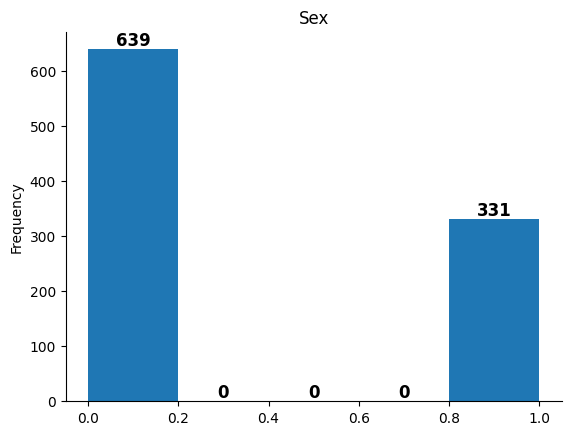

In [7]:
#checking for imbalance between genders
ax=labels_train['Sex_F'].plot(kind='hist', bins=5, title='Sex')
plt.gca().spines[['top', 'right',]].set_visible(False)
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{int(height)}',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

### Sex Distribution in Dataset

The bar chart shows the distribution of participants by sex:

- **0 = Male:** 639 samples  
- **1 = Female:** 331 samples

#### Insight:
There is a noticeable imbalance, with **almost twice as many males** as females. This imbalance may contribute to the model's bias and lower performance in predicting female-related outcomes, reinforcing the need for fairness-aware modeling and evaluation.


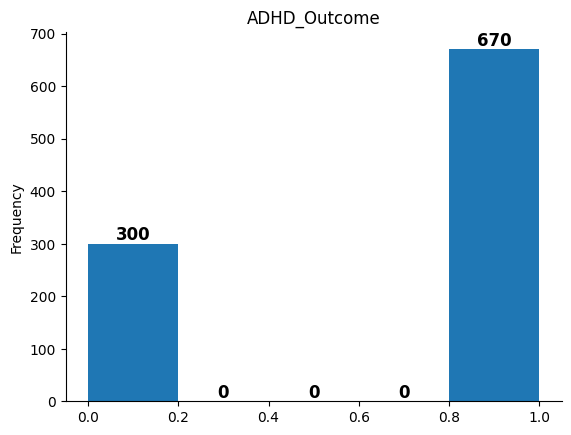

In [8]:
#CHeking the imbalance
ax=labels_train['ADHD_Outcome'].plot(kind='hist',bins=5, title='ADHD_Outcome')
plt.gca().spines[['top', 'right',]].set_visible(False)
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{int(height)}',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

### ADHD Outcome Distribution

The bar chart displays the distribution of ADHD diagnoses in the dataset:

- **0 = No ADHD:** 300 samples  
- **1 = ADHD:** 670 samples

#### Insight:
The dataset is imbalanced, with more than twice as many ADHD cases as non-ADHD. This imbalance can affect model performance and may require attention through techniques like class weighting or careful evaluation metrics (e.g., F1-score).


In [9]:
#quick check the relationship between gender and result of the Test
relation=pd.crosstab(labels['Sex_F'], labels['ADHD_Outcome'])
print(relation)
print(f"Precantage of Male ADHD={((581/(581+216))*100)}% and Precantage of Female ADHD={(250/(250+166))*100}%")

ADHD_Outcome    0    1
Sex_F                 
0             216  581
1             166  250
Precantage of Male ADHD=72.89836888331243% and Precantage of Female ADHD=60.09615384615385%


### It is concluded that the % of Male having ADHD is Higher Already which will increase the diffculty of the task


In [10]:
metadata_A_train

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
participant_id,,,,,,,,,,,,,,,,,,
GAOpTeUSloVu,100.00,0,3,6,41,15,14,27,3,7,0,7,0,4,0,0,9,12.683093
CZqxkD8oaBia,80.00,13,4,12,50,18,16,30,5,20,8,9,6,4,11,3,10,NaN
hX78DTmzeO2M,66.67,14,3,11,30,14,10,18,3,24,4,13,6,10,11,7,6,12.308008
cr1fWWRfksXe,93.34,14,3,20,42,20,15,22,4,6,0,5,0,1,1,1,8,14.052589
0i2Tz2XUL4vm,86.67,14,3,14,46,16,10,26,3,15,4,11,4,8,4,0,8,9.715491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7AaDVTBrqpwA,86.67,13,3,9,40,14,10,26,0,6,3,3,1,3,3,0,9,NaN
L8Rhj24LJV8V,100.00,14,3,18,40,16,13,27,4,23,8,14,8,10,9,1,10,7.938854
JgObbBX10G8Y,100.00,14,5,18,38,21,17,23,2,13,0,9,5,7,4,4,7,10.901095


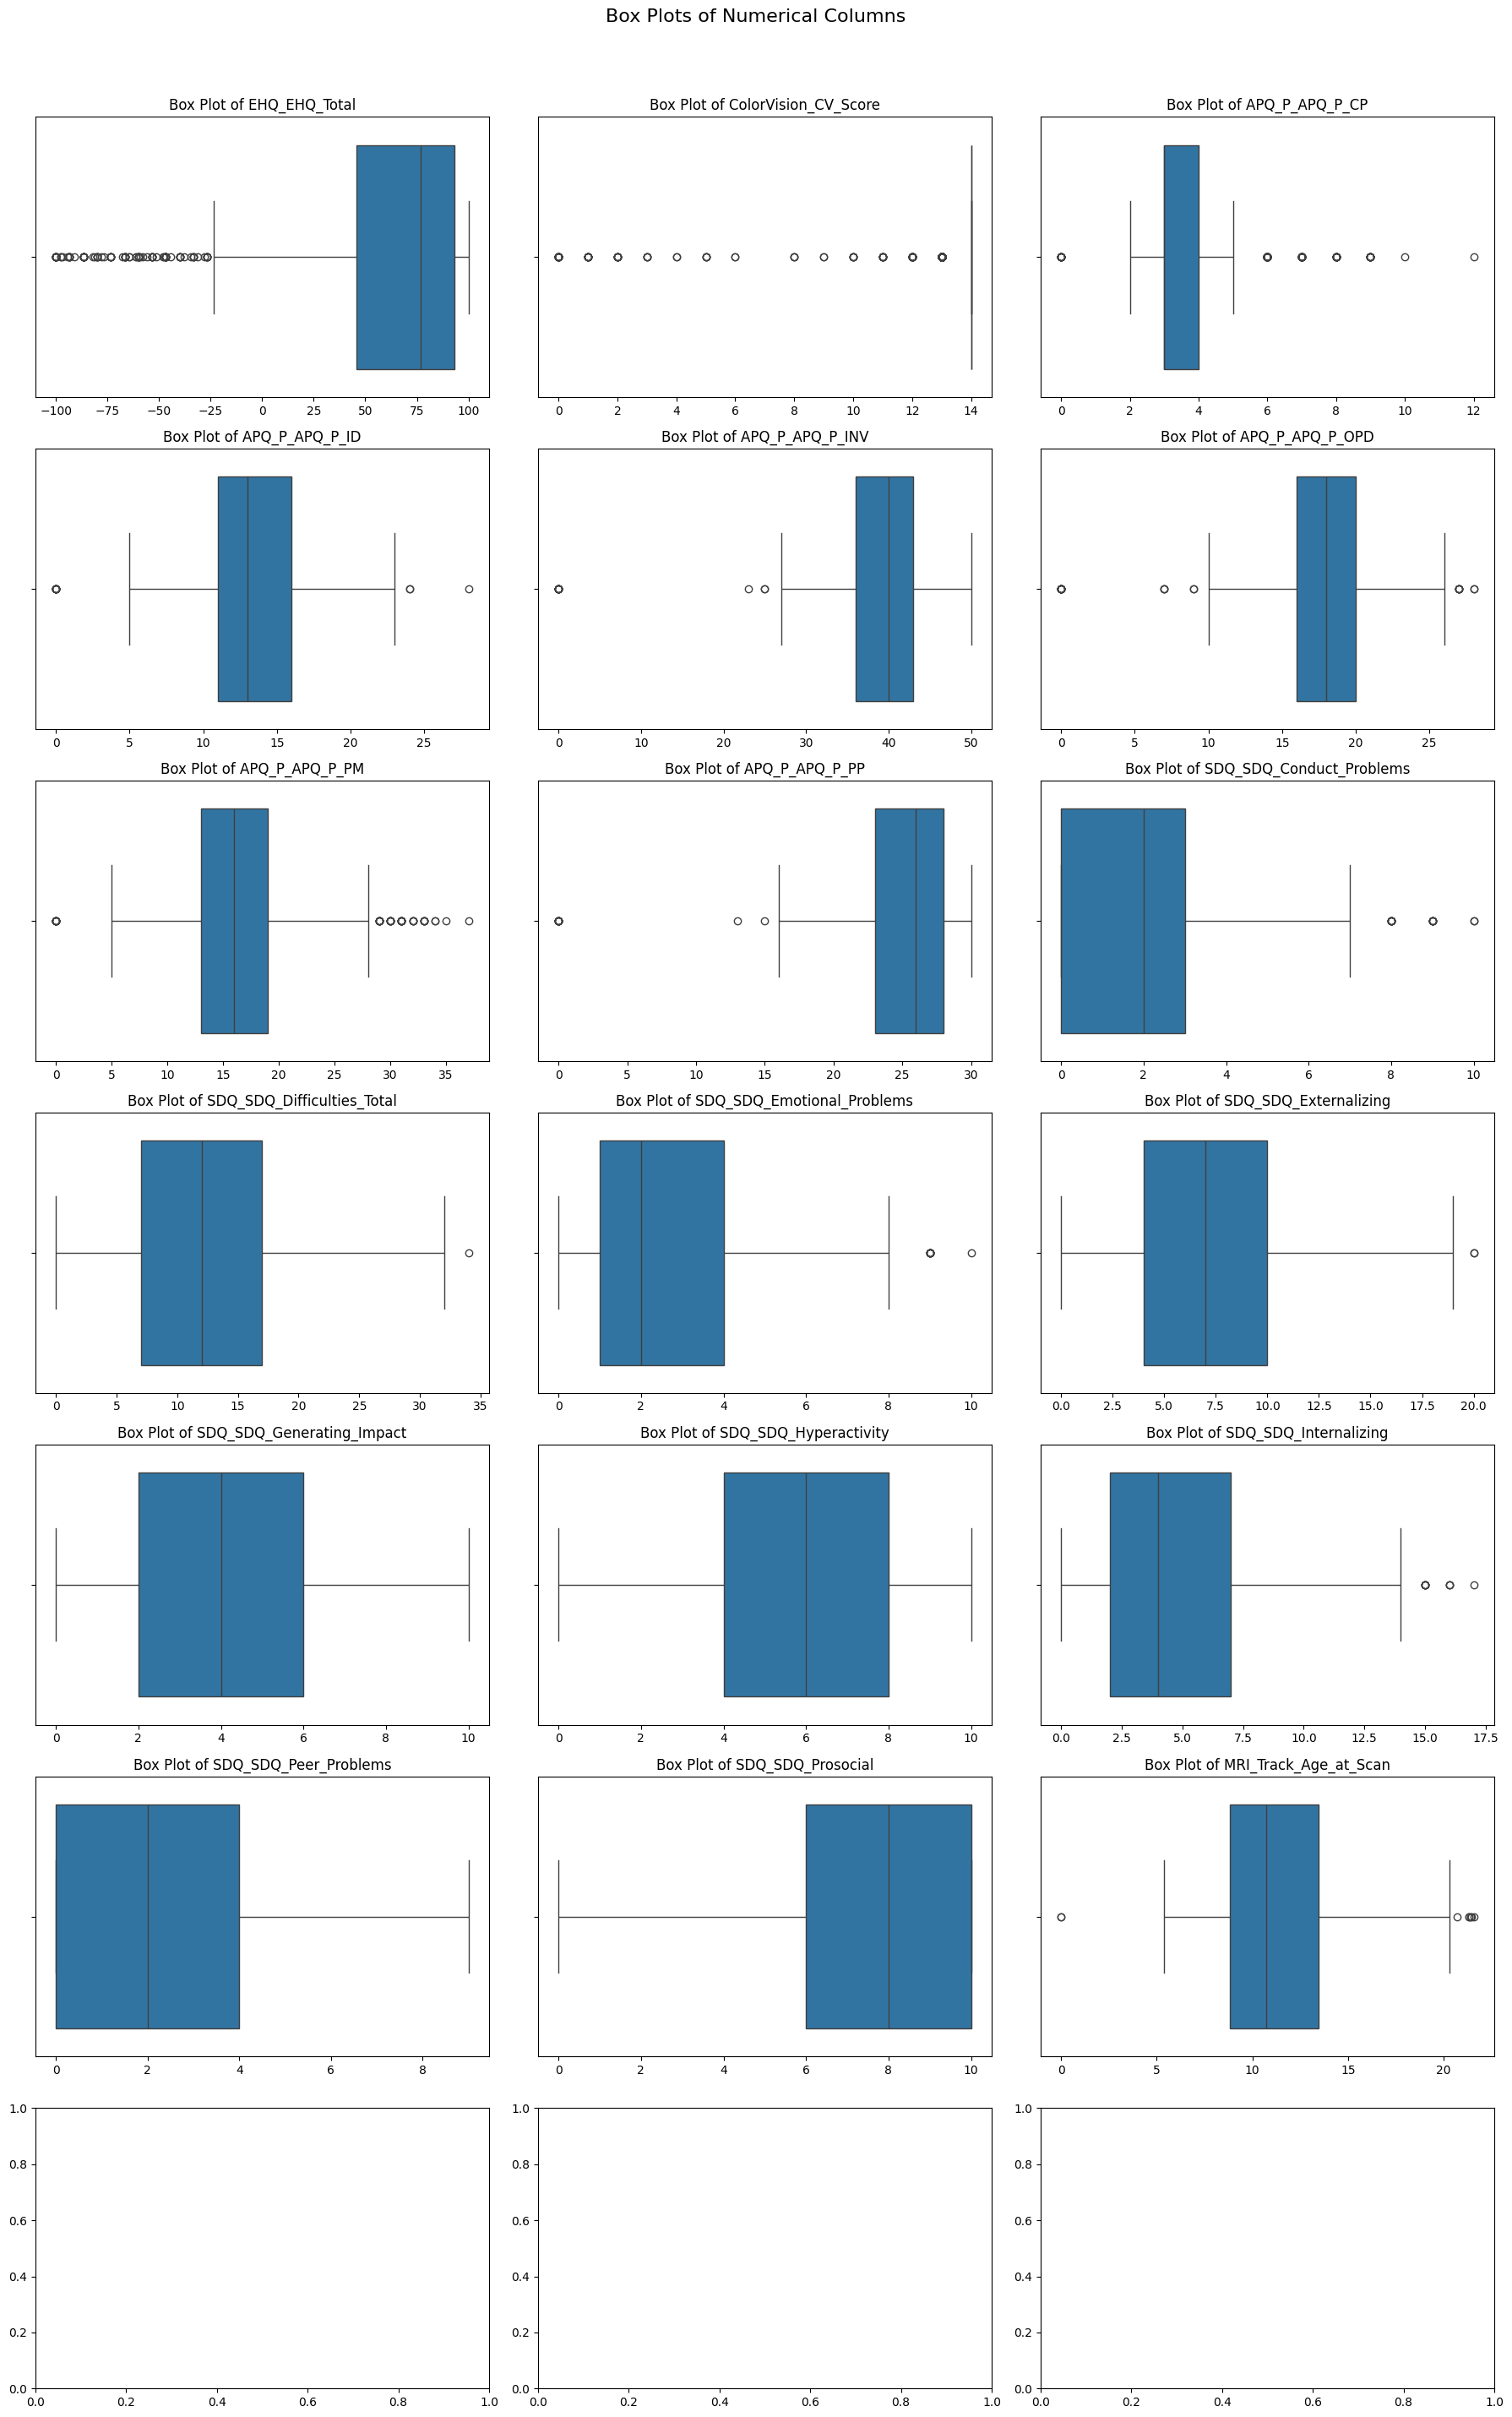

In [11]:
numerical_columns = METADATA_A.select_dtypes(include=['number'])

#Recreating the same plots but in a better structred way
n_cols = 3
n_rows = (len(numerical_columns.columns) // n_cols) +1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
fig.suptitle('Box Plots of Numerical Columns', y=1.02, fontsize=16)
axes = axes.flatten()

for i, column in enumerate(numerical_columns.columns):
    sns.boxplot(x=METADATA_A[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Box Plots of Numerical Columns

These are a series of box plots for all numerical columns in the dataset `METADATA_A`.

#### Purpose:
- To **visually inspect the distribution** of each numerical variable.
- Helps identify **outliers**, **skewness**, and **value ranges** across features.


This is a useful step in **exploratory data analysis (EDA)** to understand variability and potential preprocessing needs (e.g., normalization, outlier handling).


In [12]:
#Checking N/A
missing_values = metadata_A_train.isna().sum()
print("Number of missing values in each column:")
print(missing_values)

Number of missing values in each column:
EHQ_EHQ_Total                   0
ColorVision_CV_Score            0
APQ_P_APQ_P_CP                  0
APQ_P_APQ_P_ID                  0
APQ_P_APQ_P_INV                 0
APQ_P_APQ_P_OPD                 0
APQ_P_APQ_P_PM                  0
APQ_P_APQ_P_PP                  0
SDQ_SDQ_Conduct_Problems        0
SDQ_SDQ_Difficulties_Total      0
SDQ_SDQ_Emotional_Problems      0
SDQ_SDQ_Externalizing           0
SDQ_SDQ_Generating_Impact       0
SDQ_SDQ_Hyperactivity           0
SDQ_SDQ_Internalizing           0
SDQ_SDQ_Peer_Problems           0
SDQ_SDQ_Prosocial               0
MRI_Track_Age_at_Scan         284
dtype: int64


In [13]:
#From the correlation Graph we find that it has very low effect on the result of the ADHD_OUTCOME
#And from the amount of N/A info it has been decided to drop this column
metadata_A_train.drop('MRI_Track_Age_at_Scan', axis=1, inplace=True)
metadata_A_test.drop('MRI_Track_Age_at_Scan', axis=1, inplace=True)


After Carefully Checking each Feature and it's meaning, all the values make sense execpt for having value 0 in the MRE Track age and since this column contains 360 N/A it will be dropped so there is no need to handle this incorrect value existing

In [14]:
metadata_B_train

,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
participant_id,,,,,,,,,
GAOpTeUSloVu,2015,1,0.0,0,1,18,35,12,5
CZqxkD8oaBia,2019,3,0.0,0,2,21,45,18,0
hX78DTmzeO2M,2016,1,0.0,0,1,18,35,18,35
cr1fWWRfksXe,2017,3,0.0,1,2,21,30,0,0
0i2Tz2XUL4vm,2019,1,0.0,0,2,15,0,9,0
...,...,...,...,...,...,...,...,...,...
7AaDVTBrqpwA,2018,3,0.0,3,3,21,35,21,0
L8Rhj24LJV8V,2019,4,0.0,0,4,21,45,21,45
JgObbBX10G8Y,2019,3,0.0,1,3,6,35,0,0


Now I'll check if there are any value that doesn't correspond to the encodded meaning

0
0
0
3


Text(0.5, 1.0, 'Histogram of MRI_Track_Scan_Location')

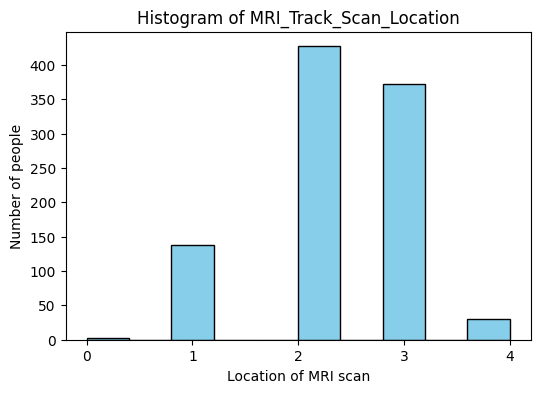

In [15]:
count=0
for i in metadata_B_train['MRI_Track_Scan_Location']:
    if i<1 or i>4:
        print(i)
        count+=1
print(count)
plt.figure(figsize=(6, 4))
plt.hist(metadata_B_train['MRI_Track_Scan_Location'], bins=10, color='skyblue', edgecolor='black')
plt.xticks(np.arange(0, 5, step=1))
plt.xlabel('Location of MRI scan')
plt.ylabel('Number of people')
plt.title('Histogram of MRI_Track_Scan_Location')

A few samples were encoded given a wrong value (0)

0
0
0
0
0
0
0
7


Text(0.5, 1.0, 'Histogram of Barratt_Barratt_P1_Edu')

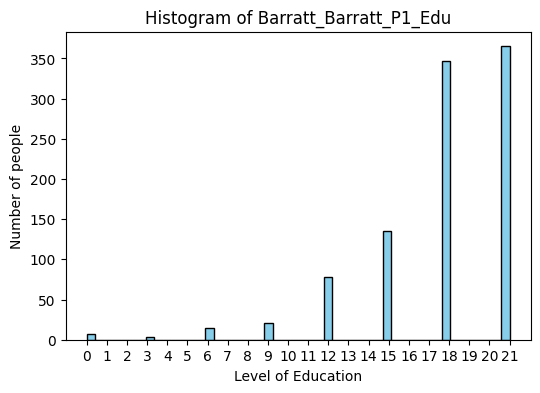

In [16]:
count=0
for i in metadata_B_train['Barratt_Barratt_P1_Edu']:
    if i!=3 and i!=6  and i!=9 and i!=12  and i!=15 and i!=18 and i!=21:
        print(i)
        count+=1
print(count)
plt.figure(figsize=(6, 4))
plt.hist(metadata_B_train['Barratt_Barratt_P1_Edu'], bins=50, color='skyblue', edgecolor='black')
plt.xticks(np.arange(0, 22, step=1))
plt.xlabel('Level of Education')
plt.ylabel('Number of people')
plt.title('Histogram of Barratt_Barratt_P1_Edu')

According to the encodding dictionary there shouldn't be any samples containing value 0 for this Feature

the amount of miscodded data is 160


Text(0.5, 1.0, 'Histogram of Barratt_Barratt_P2_Edu')

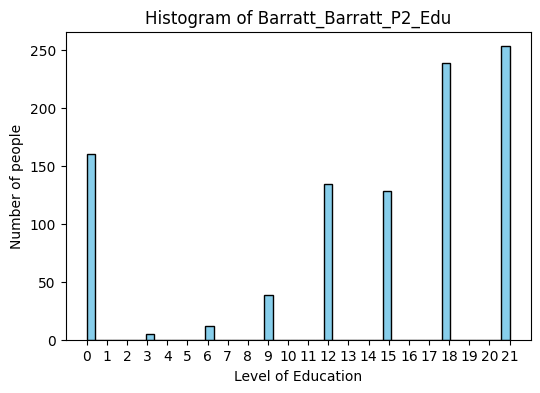

In [17]:
count=0
for i in metadata_B_train['Barratt_Barratt_P2_Edu']:
    if i!=3 and i!=6  and i!=9 and i!=12  and i!=15 and i!=18 and i!=21:
        count+=1
print("the amount of miscodded data is",count)

plt.figure(figsize=(6, 4))
plt.hist(metadata_B_train['Barratt_Barratt_P2_Edu'], bins=50, color='skyblue', edgecolor='black')
plt.xticks(np.arange(0, 22, step=1))
plt.xlabel('Level of Education')
plt.ylabel('Number of people')
plt.title('Histogram of Barratt_Barratt_P2_Edu')

Here we can observe that there are alot of samples misencodded which will increase the likelyhood of removing this feature if it appeares ineffective to the predction

In [18]:
#Checking N/A
missing_values = metadata_B_train.isna().sum()
print("Number of missing values in each column:")
print(missing_values)

Number of missing values in each column:
Basic_Demos_Enroll_Year             0
Basic_Demos_Study_Site              0
PreInt_Demos_Fam_Child_Ethnicity    9
PreInt_Demos_Fam_Child_Race         0
MRI_Track_Scan_Location             0
Barratt_Barratt_P1_Edu              0
Barratt_Barratt_P1_Occ              0
Barratt_Barratt_P2_Edu              0
Barratt_Barratt_P2_Occ              0
dtype: int64


The NA values in this feature can be filled wit the value "3" wich is encodded value for unknown

In [19]:
#After Checking the dictionary it has been decided to replace the N/A with 3 with corresponds to UNKNOWN
metadata_B_train['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3, inplace=True)
metadata_B_test['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3, inplace=True)
#After checking the correlation and the number of invalid inputs in this column it has been decided to drop the whole column
metadata_B_train.drop('Barratt_Barratt_P2_Edu', axis=1, inplace=True)
metadata_B_test.drop('Barratt_Barratt_P2_Edu', axis=1, inplace=True)

<ipython-input-19-5491f2e1ed5e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata_B_train['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3, inplace=True)
<ipython-input-19-5491f2e1ed5e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

It has been found that feature MRI_Track_Scan_Location contains 3 misencodded data and feature Barratt_Barratt_P1_Edu contains 15 misencodded data and feature Barratt_Barratt_P2_Edu contains 198 misencodded data

In [20]:
Brains.head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.093473,0.146902,0.067893,0.015141,0.070221,0.063997,0.055382,-0.035335,0.068583,...,0.003404,-0.010359,-0.050968,-0.014365,0.128066,0.112646,-0.058980,0.028228,0.133582,0.143372
1,WHWymJu6zNZi,0.029580,0.179323,0.112933,0.038291,0.104899,0.064250,0.008488,0.077505,-0.004750,...,-0.008409,-0.008479,0.020891,0.017754,0.094040,0.035141,0.032537,0.075007,0.115350,0.138200
2,4PAQp1M6EyAo,-0.051580,0.139734,0.068295,0.046991,0.111085,0.026978,0.151377,0.021198,0.083721,...,0.053245,-0.028003,0.028773,0.024556,0.166343,0.058925,0.035485,0.063661,0.042862,0.162162
3,obEacy4Of68I,0.016273,0.204702,0.115980,0.043103,0.056431,0.057615,0.055773,0.075030,0.001033,...,-0.023918,-0.005356,0.018607,0.016193,0.072955,0.130135,0.056120,0.084784,0.114148,0.190584
4,s7WzzDcmDOhF,0.065771,0.098714,0.097604,0.112988,0.071139,0.085607,0.019392,-0.036403,-0.020375,...,0.066439,-0.076680,-0.047530,-0.031443,0.221213,0.007343,0.005763,0.083820,0.079582,0.067269


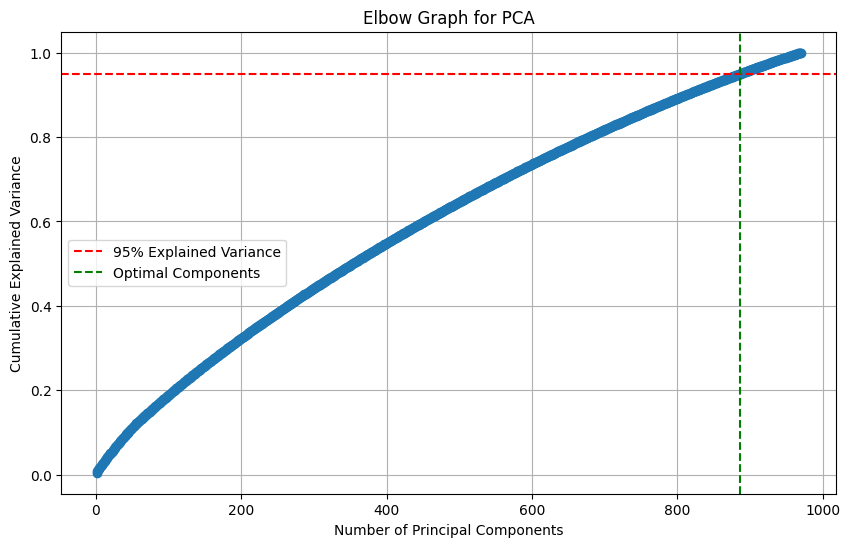

Optimal number of principal components: 886
Transformed training data with optimal components:


,participant_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC877,PC878,PC879,PC880,PC881,PC882,PC883,PC884,PC885,PC886
0,70z8Q2xdTXM3,-2.008234,1.370619,-5.729546,3.389876,-1.403093,-0.686055,1.137467,2.737976,1.077125,...,-2.938530,-2.867887,2.154235,-0.591491,-2.541921,-7.578631,4.925317,9.257358,-1.022988,-7.655468
1,WHWymJu6zNZi,-10.035630,9.919105,-1.633466,2.294617,-1.726869,-3.434870,1.458518,-0.462197,8.418257,...,1.678860,2.152697,2.378746,0.648725,-0.725984,1.978445,-0.327680,-0.774460,-0.464057,2.261263
2,4PAQp1M6EyAo,-2.790179,11.911609,3.435073,1.889352,-0.576595,-0.088775,-0.841713,-2.773005,2.063967,...,5.523409,8.365916,-10.058219,4.956115,6.147924,1.528931,-9.255933,-0.945739,-3.063185,2.461425
3,obEacy4Of68I,2.728194,-10.655773,-0.795750,-0.941643,1.132576,-0.998186,1.876101,1.730126,-2.352961,...,-0.385303,1.897261,5.323128,-3.995364,2.805919,-1.673522,2.929626,1.340008,4.355274,1.469011
4,sId1cQF5F22m,-19.858644,-8.031640,-10.731156,-1.001446,-4.213402,-3.306120,-1.376752,-0.273071,-0.640781,...,0.269663,0.307582,-0.123086,-0.102555,-2.067818,-1.302037,-0.455855,0.049129,-0.285068,-1.477252


Transformed test data with optimal components:


,participant_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC877,PC878,PC879,PC880,PC881,PC882,PC883,PC884,PC885,PC886
0,s7WzzDcmDOhF,-7.467906,1.900722,3.233643,1.411352,0.585693,2.442482,0.935372,1.679360,0.469284,...,-0.255627,-0.351020,-0.335913,-0.959886,-0.790796,0.069170,0.907785,-1.782272,-1.119747,0.684768
1,s55ZRHrJtnlL,-4.220081,9.971465,0.489247,-0.491609,-1.895500,-0.721776,-1.560770,-1.097511,0.881364,...,0.900657,-0.360310,0.526848,-0.702014,0.010878,0.874566,0.930813,0.314129,-0.179226,-0.690822
2,VZnIq2hRErI5,-2.476684,12.764841,5.814522,1.518341,1.532553,0.363257,1.796780,0.112700,-1.565608,...,0.073086,-0.020815,0.369031,-1.444500,-0.514835,0.147863,0.850743,1.364679,0.329306,0.962236
3,dI23GWHeIH06,1.377396,-2.833587,6.965642,0.654803,1.897108,0.532939,-1.041367,-0.121725,0.581507,...,0.378837,-0.437493,-1.677618,1.166571,-1.905931,0.957506,1.229116,1.182962,-0.255598,1.010268
4,bkTAb6Mpe2xp,-4.082060,11.850235,-2.470976,-2.155909,2.318855,0.042999,-1.373495,0.151004,1.514218,...,-0.931168,0.667574,-0.703612,2.707805,0.206291,0.648647,0.505884,1.481844,-1.412212,-1.271152


['pca_model.joblib']

In [21]:
#Separate features from IDs for both train and test
X_train = Brains_train.drop('participant_id', axis=1)
train_ids = Brains_train['participant_id']

X_test = Brains_test.drop('participant_id', axis=1)
test_ids = Brains_test['participant_id']

#Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)

#Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Elbow Graph for PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=np.argmax(cumulative_explained_variance >= 0.95) + 1, color='g', linestyle='--', label='Optimal Components')
plt.legend()
plt.grid()
plt.savefig('pca_elbow_graph.png', dpi=300)
plt.show()

optimal_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Optimal number of principal components: {optimal_components}")

#Using optimal values for PCA
pca_optimal = PCA(n_components=optimal_components)
pca_optimal.fit(X_train_scaled)  # Only fit on training data

#Transforming both training and test data with the same fitted PCA (making sure not to fit the testing set)
X_train_pca = pca_optimal.transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(optimal_components)])
test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(optimal_components)])

# Add IDs - maintain the correct index alignment by using the original DataFrame's index
train_pca_df['participant_id'] = Brains_train['participant_id'].reset_index(drop=True)
test_pca_df['participant_id'] = Brains_test['participant_id'].reset_index(drop=True)

# If you want participant_id as the first column
cols = train_pca_df.columns.tolist()
cols = [cols[-1]] + cols[:-1]  # Move last column to first position
train_pca_df = train_pca_df[cols]
test_pca_df = test_pca_df[cols]

# Display results
print("Transformed training data with optimal components:")
display(train_pca_df.head())

print("Transformed test data with optimal components:")
display(test_pca_df.head())

#saving the PCA model to use it on new data
joblib.dump(pca_optimal, 'pca_model.joblib')

## PCA

The elbow graph above illustrates the cumulative explained variance as a function of the number of principal components used in the PCA (Principal Component Analysis) transformation.

#### Interpretation:
- The **red dashed line** represents the threshold for **95% explained variance**, a common benchmark for retaining sufficient data variance.
- The **green dashed line** marks the **optimal number of components** (886) needed to retain 95% of the total variance.
- The graph shows a typical elbow shape, where the benefit of adding more components starts to diminish beyond the optimal point.

#### Insight:
Using **886 components** allows the model to retain most of the important information while significantly reducing dimensionality. This step is essential for improving model performance and efficiency when working with high-dimensional fMRI data.


In [41]:
#making sure that the amount of samples are correct in the training dataset
train_pca_df.shape

(970, 887)

In [42]:
#MErging datasets on participant_id
data = pd.merge(labels, metadata_A_train, on='participant_id')
data = pd.merge(data, metadata_B_train, on='participant_id')
#data = pd.merge(data, pca_df, on='participant_id')
print(data.shape)

print("Merged dataset preview:")
display(data.head())

(970, 27)
Merged dataset preview:


,ADHD_Outcome,Sex_F,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,...,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Occ
participant_id,,,,,,,,,,,,,,,,,,,,,
UmrK0vMLopoR,1,1,40.00,13,3,10,47,13,11,28,...,0,10,2016,1,0.0,0,1,21,45,45
CPaeQkhcjg7d,1,0,-94.47,14,3,13,34,18,23,30,...,4,5,2019,3,1.0,2,3,15,15,0
Nb4EetVPm3gs,1,0,-46.67,14,4,10,35,16,10,29,...,4,9,2016,1,1.0,8,1,18,40,0
p4vPhVu91o4b,1,1,-26.68,10,5,12,39,19,16,28,...,4,6,2018,3,0.0,8,3,15,30,0
tBGXkEdv2cp7,1,0,83.34,2,5,12,35,16,15,21,...,5,3,2018,1,0.0,8,3,21,0,45


Top 10 features correlated with ADHD_Outcome:


,ADHD_Outcome
ADHD_Outcome,1.000000
SDQ_SDQ_Hyperactivity,0.556516
SDQ_SDQ_Externalizing,0.521140
SDQ_SDQ_Difficulties_Total,0.464826
SDQ_SDQ_Generating_Impact,0.415712
SDQ_SDQ_Conduct_Problems,0.299725
SDQ_SDQ_Internalizing,0.249434
SDQ_SDQ_Peer_Problems,0.209383
SDQ_SDQ_Emotional_Problems,0.204299
APQ_P_APQ_P_OPD,0.155971


<ipython-input-43-1660fe90060d>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=correlation_with_adhd.values, y=correlation_with_adhd.index, palette='viridis')


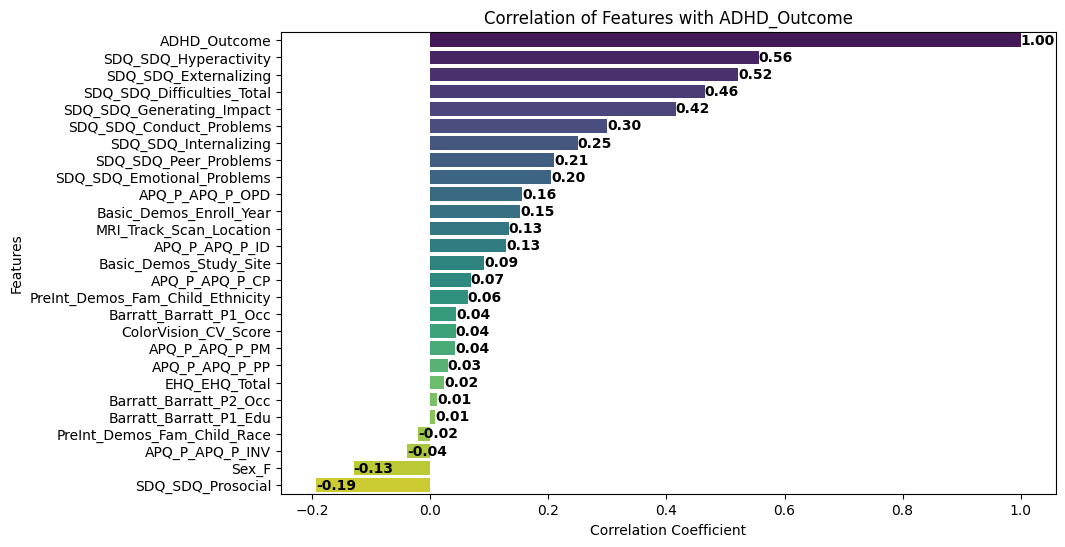

In [43]:
# Calculate correlation with ADHD_Outcome
correlation_with_adhd = data.corr()['ADHD_Outcome'].sort_values(ascending=False)

# Display top 10 most correlated features
print("Top 10 features correlated with ADHD_Outcome:")
display(correlation_with_adhd.head(10))

# Visualize correlation
plt.figure(figsize=(10, 6))
ax=sns.barplot(x=correlation_with_adhd.values, y=correlation_with_adhd.index, palette='viridis')
for index, value in enumerate(correlation_with_adhd.values):
    ax.text(value, index, f'{value:.2f}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.title('Correlation of Features with ADHD_Outcome')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.savefig('correlation_with_adhd.png', dpi=300)
plt.show()

### Correlation of Features with ADHD Outcome

The bar chart displays the **correlation coefficients** between various features and the `ADHD_Outcome` variable, helping identify the most influential predictors.

#### Key Insights:
- **Strongest positive correlations**:
  - `SDQ_Hyperactivity` (0.56)
  - `SDQ_Externalizing` (0.52)
  - `SDQ_Difficulties_Total` (0.46)
  - `SDQ_Generating_Impact` (0.42)
  These are directly related to behavioral assessments and support their importance in ADHD prediction.

- **Weak or negligible correlations**:
  - Demographics and parental data such as `ColorVision_CV_Score`, `Barratt_P1_Occ`, and `EHQ_Total` show minimal correlation (< 0.05).
  
- **Negative correlations**:
  - `SDQ_Prosocial` (-0.19) and `Sex_F` (-0.13), suggesting females and prosocial behaviors are slightly associated with lower ADHD diagnosis.

#### Conclusion:
Behavioral metrics from the SDQ questionnaire are highly predictive of ADHD outcomes. These correlations justify their inclusion in the model and align with clinical expectations.


Top 10 features correlated with Sex:


,Sex_F
Sex_F,1.000000
SDQ_SDQ_Prosocial,0.112574
ColorVision_CV_Score,0.079304
SDQ_SDQ_Emotional_Problems,0.076526
Barratt_Barratt_P1_Occ,0.068286
Barratt_Barratt_P1_Edu,0.065215
SDQ_SDQ_Internalizing,0.032996
EHQ_EHQ_Total,-0.001258
PreInt_Demos_Fam_Child_Race,-0.009356
SDQ_SDQ_Peer_Problems,-0.024616


<ipython-input-44-2b92fbe1328f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=correlation_with_adhd.values, y=correlation_with_adhd.index, palette='viridis')


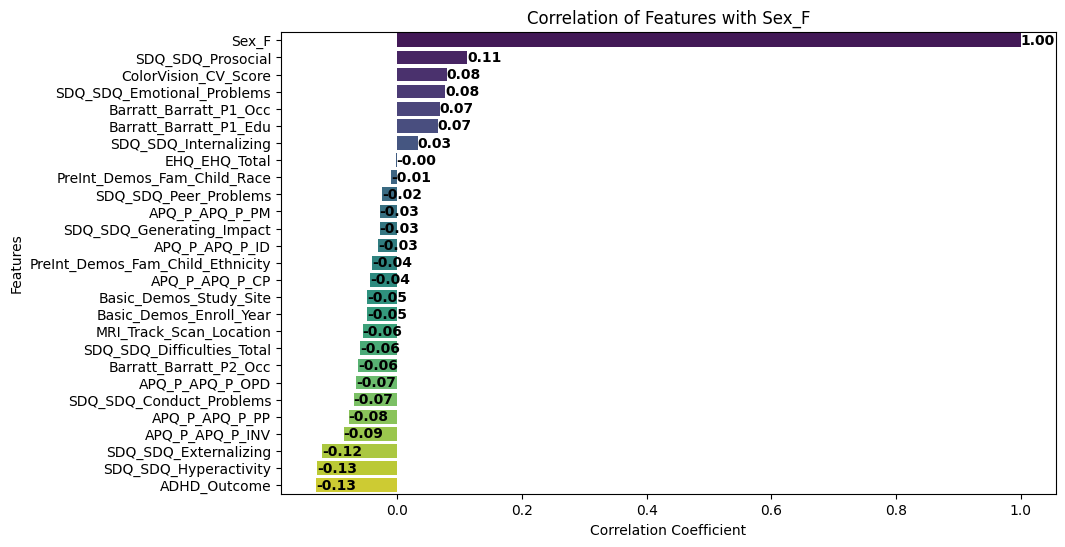

In [44]:
# Calculate correlation with ADHD_Outcome
correlation_with_adhd = data.corr()['Sex_F'].sort_values(ascending=False)

# Display top 10 most correlated features
print("Top 10 features correlated with Sex:")
display(correlation_with_adhd.head(10))

# Visualize correlation
plt.figure(figsize=(10, 6))
ax=sns.barplot(x=correlation_with_adhd.values, y=correlation_with_adhd.index, palette='viridis')
for index, value in enumerate(correlation_with_adhd.values):
    ax.text(value, index, f'{value:.2f}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.title('Correlation of Features with Sex_F')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.savefig('correlation_with_sex.png', dpi=300)
plt.show()

### Correlation of Features with Sex (Female)

The bar chart shows the **correlation of each feature with `Sex_F`**

#### Key Insights:
- Most features show **very weak correlation** with sex, indicating limited gender-specific patterns in the dataset.
- Slight **positive correlations** are seen with:
  - `SDQ_Prosocial` (0.11)
  - `ColorVision_CV_Score` (0.08)
  - `SDQ_Emotional_Problems` (0.08)

- **Negative correlations** include:
  - `SDQ_Hyperactivity` (-0.13)
  - `SDQ_Externalizing` (-0.13)
  - `ADHD_Outcome` (-0.13)

#### Conclusion:
- Females tend to score slightly higher in prosocial and emotional traits.
- Males are more associated with externalizing behaviors and ADHD diagnoses.
- These mild correlations suggest that **behavioral features do capture subtle gender-linked patterns**, which can inform fairness-aware modeling.
- We Can get rid of EHQ_EHQ_total ,Barratt_Barratt_p1/P2_EDU since it's shown that it has very low to 0 effect on the prediction of ADHD_OUTCOME and SEX_F

Text(0.5, 1.0, 'Correlation heatmap')

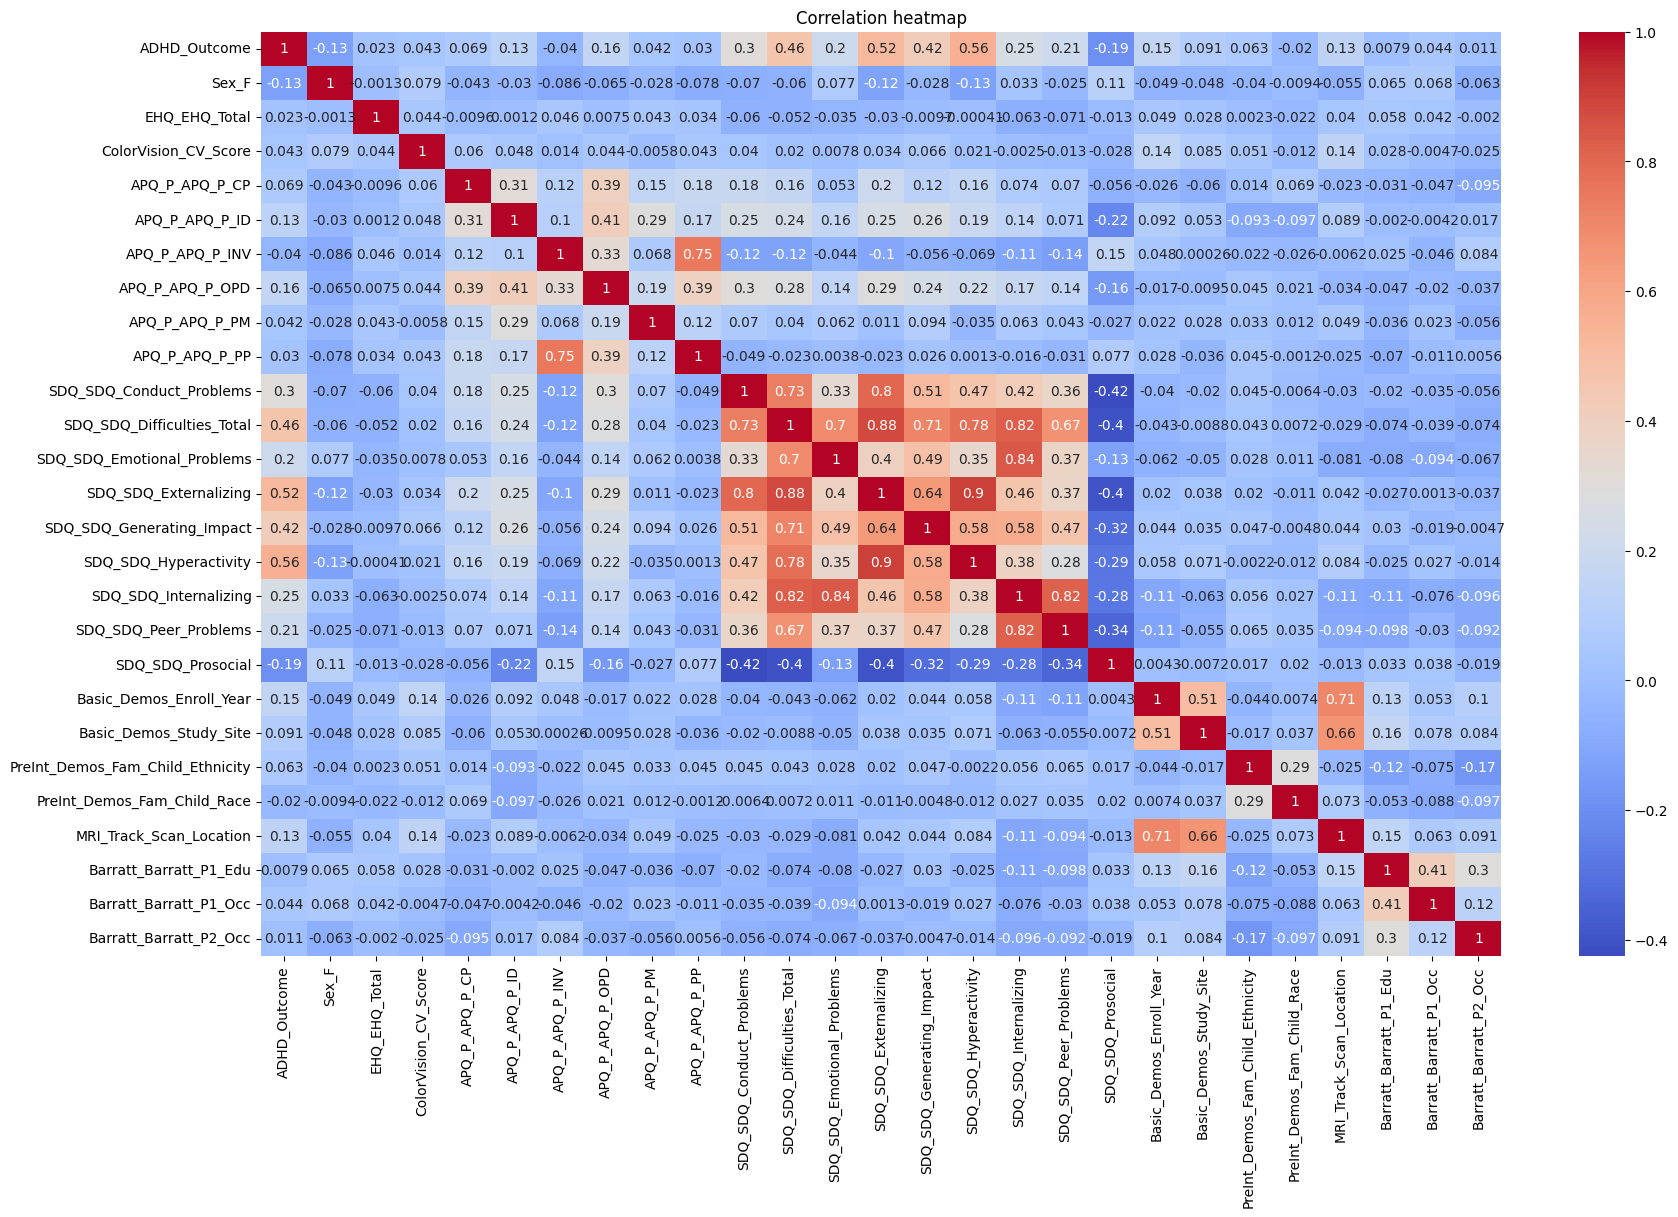

In [45]:
corr=data.corr()
#print(corr)
# Plot a heatmap of the correlations between pairs of FEATURES (i.e., don't include the target!)
plt.figure(figsize=(20,12))
heatmap=sns.heatmap(corr,annot=True,cmap='coolwarm') #so the color grad change by changing cmap and the annot is for the numbers on the bricks
heatmap.set_title("Correlation heatmap")

There is a clear relation between Hyperactivity and externalzing which can make us drop the extranalzing column to speed up the processes
but since both of these columns are very corelated to the ADHD_OUTCOME so it's better to leave them both first to increase the accuracy but at the same time keep an eye on for overfitting

In [46]:
#ensureing that merging METADATA_A and METADATA_B is correct
data.shape

(970, 27)

In [47]:
#Merging the data with the Final dataset after running PCA on it
data_training_all = pd.merge(data, train_pca_df, on='participant_id')
data_training_all.shape

(970, 914)

In [48]:
#droping the rows with wrong encodded data since they are inly 18 rows total
#and dropping the column with so little effect on the prediction of both labels
data_training_all = data_training_all[data_training_all["MRI_Track_Scan_Location"] != 0]
data_training_all = data_training_all[data_training_all["Barratt_Barratt_P1_Edu"] != 0]
data_training_all.drop('EHQ_EHQ_Total', axis=1, inplace=True)

In [49]:
data_training_all

,participant_id,ADHD_Outcome,Sex_F,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,...,PC877,PC878,PC879,PC880,PC881,PC882,PC883,PC884,PC885,PC886
0,UmrK0vMLopoR,1,1,13,3,10,47,13,11,28,...,-2.613583,-0.516286,1.008687,1.572358,1.300220,-1.521963,0.857135,-1.264311,-0.424675,2.464492
1,CPaeQkhcjg7d,1,0,14,3,13,34,18,23,30,...,1.915436,-3.487342,-4.513927,4.707504,7.351299,-2.050361,9.192267,-7.717723,-5.083021,1.534352
2,Nb4EetVPm3gs,1,0,14,4,10,35,16,10,29,...,-0.159691,-0.996984,0.048197,-1.362562,-1.645124,2.827400,0.871389,0.672213,-1.972764,0.084515
3,p4vPhVu91o4b,1,1,10,5,12,39,19,16,28,...,-7.516582,0.639295,-3.214653,-1.092424,-1.455798,2.524748,-2.259480,0.356083,-1.958436,-1.056986
4,tBGXkEdv2cp7,1,0,2,5,12,35,16,15,21,...,-5.143800,1.701604,1.203452,2.693757,-1.161223,-0.417290,1.029051,1.753904,-8.989351,2.129899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,8RqLpySUwmWx,0,0,14,3,6,49,21,14,30,...,4.831881,0.187517,-1.385743,-0.437576,-9.819880,0.965880,8.906887,0.968686,0.576473,-7.537363
966,Zusa1n9tQ3Yb,0,1,14,5,20,45,21,20,29,...,1.149759,-2.377627,3.418888,0.169010,1.411631,-0.068036,-5.413360,3.002062,-3.182280,-9.654571
967,Atx7oub96GXS,0,0,14,5,14,39,20,15,21,...,0.030232,1.760884,8.255866,-6.852187,-3.732215,-0.739331,2.402540,-3.491589,-2.205195,-2.100957
968,groSbUfkQngM,0,1,14,3,10,32,20,11,23,...,2.503983,0.942618,-1.318643,-3.226215,-0.542434,-3.382246,-1.303640,2.219939,-1.598742,0.005196


We end up with 1195 samples that are correctly encooded and doesn't have any problems to be used as inputs and 1130 features that accumlates the most important and effective information for the model to work with

In [50]:
#creating the testing final dataset by merging the testing data
data_testing_all = pd.merge(labels_test, metadata_A_test, on='participant_id')
data_testing_all = pd.merge(data_testing_all, metadata_B_test, on='participant_id')
data_testing_all = pd.merge(data_testing_all, test_pca_df, on='participant_id')
data_testing_all.drop('EHQ_EHQ_Total', axis=1, inplace=True)
data_testing_all.shape

(243, 913)

In [51]:
#Saving the datasets to a CSV file
data_training_all.to_csv('training_data.csv', index=False)
data_testing_all.to_csv('testing_data.csv', index=False)
